<div style="
    background-color: #FFF0F5;
    padding: 25px;
    border-radius: 15px;
    border: 2px solid #FFB6C1;">
    <h1 style="
        color: #C71585;
        text-align: center;
        font-family: 'Georgia', serif">
        🌸 Sprawozdanie z Laboratorium z CPSIO 🌸
    </h1>
    <h2 style="
        color: #DB7093;
        text-align: center;">
        Przetwarzanie i analiza sygnału EKG
    </h2>
    <p style="
        text-align: center;
        color: #8B0A50;">
        <b>
            Autorzy:
        </b> 
        Damian Ryczko, Małgorzata Sokołowska
    </p>
</div>

### 1. Cel laboratorium 
Głównym celem wykonywanych zadań jest zapoznanie się z metodami cyfrowego przetwarzania sygnałów biomedycznych na przykładzie elektrokardiogramu (EKG). W ramach sprawozdania zrealizowano cztery główne zagadnienia:
1. **Wczytywanie i wizualizacja:** Zbudowanie interaktywnego narzędzie do eksploracji danych.
2. **Analiza w dziedzinie częstotliwości:** Badanie dyskretnej transformaty Fouriera (DFT) na sygnałach syntetycznych (sinusoidalnych) w celu zrozumienia jej właściwości oraz odwracalności (IDFT).
3. **Analiza widmowa EKG:** Zastosowanie poznanego (w punkcie 2) aparatu matematycznego do analizy rzeczywistego sygnału biomedycznego.
4. **Cyfrowa filtracja sygnałów:** Zaprojektowanie i implementacja filtrów o skończonej i nieskończone odpowidzi impulsowej (w tym przypadku filtrów Butterwortha) w celu usunięcia typowych artefaktów: szumu sieciowego (50/60 Hz) oraz izolinii (pływania linii izoelektrycznej, tzw. *baseline wander*).

*Dokument zawiera pełen proces realizacji zadań z zakresu wczytywania, wizualizacji, analizy oraz filtracji sygnałów elektrokardiograficznych (EKG).*

In [46]:
#library imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from scipy.signal import butter, filtfilt, freqz
from scipy.fft import  fft, fftfreq

# Pretty colors setup for all plots
plt.style.use('ggplot')
plt.rcParams.update({
    'axes.prop_cycle' : plt.cycler(color=['#FF1493', '#DB7093', '#FF69B4', '#C71585', '#FFB6C1']),
    'axes.facecolor' : '#FFF0F5',       # LavenderBlush
    'figure.facecolor' : '#FFE4E1',     # MistyRose
    'axes.edgecolor' : '#DB7093',       # PaleVioletRed
    'axes.labelcolor' : '#C71585',      # MediumVioletRed    
    'xtick.color' : '#DB7093',
    'ytick.color' : "#DB7093",
    'grid.color' : '#FFC0CB',           # Pink
    'lines.color' : '#FF69B4',           # HotPink
    'lines.linewidth' : 2
})

---
# **Ćwiczenie 1: System wczytywania i interaktywnej wizualizacji danych**

Sygnały medyczne zapisywane są w rónych formatach. W tym ćwiczeniu pracujemy z plikami tekstowymi ('.txt'), w których wiersze to kolejne próbki, a kolumny to kanały pomiarowe. Zbudowany ponizej system oparty na bibliotekach 'pandas' oraz 'ipywidgets' rozwiązuje problem statycznych wykresów - pozwala uzytkownikowi na "przesuwanie" się wzdłuz osi czasu, przyblizanie konkretnych fragmentów wykresu i dynamiczne skalowanie obu osi.
Zaimplementowano równiez funkcję pozwalającą na natychmiastowy eksport (zapis) obserwowanego fragmentu do nowego pliku.

### **Etap1: Wstępne wczytanie i inspekcja struktury danych**
Zanim przystąpimy do budowy intaeraktywnego narzędzia, musimy zweryfikować strukturę plików źródłowych. Zgodnie z instrukcją, plik 'ekg1.txt' powinien zawierać 12 kolumn odpowiadających poszczególnym odprowadzeniom. Do wczytania danych wykorzystujemy bibliotekę 'pandas', która automatycznie zorganizuje dane w formie ramki (DataFrame), ułatwiając późniejszą manipulację sygnałem. Dlatego wyświetlimy pierwsze 10 wierszy

In [10]:
load_filename = 'data/ekg1.txt' #path to the EKG data file 
df = pd.read_csv(load_filename, sep=' ', header=None)

# Display the first few rows of the DataFrame to verify it loaded correctly
df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11
0,106,335,228,-227,-59,291,-392,-45,443,372,908,395
1,106,335,228,-227,-59,291,-392,-45,443,372,908,395
2,106,325,219,-219,-60,284,492,837,239,372,908,405
3,86,306,219,-214,-55,274,487,832,240,404,179,-63
4,96,320,224,-195,-65,264,492,842,244,404,174,-62
5,106,325,219,-207,-62,274,492,832,235,414,189,-52
6,96,335,238,-214,-55,274,492,836,235,399,174,-67
7,96,325,228,-214,-70,288,492,831,230,399,174,-62
8,116,335,219,-209,-65,279,487,825,230,394,174,-67
9,101,335,233,-224,-50,279,492,835,240,394,164,-86


### **Etap2: Weryfikacja wymiarów i liczby próbek**
Waznym elementem w cyfrowym przetwarzaniu sygnałów jest znajomość liczby próbek oraz liczby kanałów. Dzięki metodzie '.shape' sprawdzamt, czy wczytany zbiór danych jest kompletny. Wiedząc, ze częstotliwość próbkowania dla tego pliku wynosi $fs = 1000 HZ$, na podstawie liczby wierszy będziemy mogli w kolejnych krokach precyzyjnie wyliczyć czas trwania całego nagrania.

In [11]:
# Check the shape of the DataFrame to understand how many rows and columns it contains
df.shape

(5000, 12)

### **Etap3: Implementacja rdzenia wizalizacji**
Skoro wiemy juz, ze plik z danymi wczytuje się poprawnie i znamy strukturę ramki danych, mozemy przejsc do napisania docelowych narzędzi. Pierwszym z nnich będzie 'plot_signals'.

Głównym wyzwaniem jest tutaj fakt, ze uzytkownik operuje na **sekundach**, natomiast komputer potrzebuje **indeksów** próbek. Funkcja ta dynamicznie przelicza te wartości w oparciu o częstotliwość próbkowania ($fs$) oraz automatycznie dostosowuje liczbę wykresów do liczby kanałów wykrytych w pliku. Dzięki temu narzędzie jest uniwersalne dla kazdego z badanych plików EKG.

In [12]:
def plot_signals(df: pd.DataFrame, signal_start: float, signal_end: float, signal_frequency: float, y_scale: float, y_axis_title: str, x_axis_title: str) -> None:
    """Plots the signals from the DataFrame based on the specified parameters.
    Parameters:
    df (pd.DataFrame): The DataFrame containing the signal data.
    signal_start (float): The starting point of the signal to plot (in seconds).
    signal_end (float): The ending point of the signal to plot (in seconds).
    signal_frequency (float): The frequency of the signal (in Hz).
    y_scale (float): The scale for the y-axis limits.
    y_axis_title (str): The title for the y-axis.
    x_axis_title (str): The title for the x-axis.
    """
    plt.close('all')
    fig, axes = plt.subplots(df.shape[1], 1, figsize=(16, df.shape[1] * 4), sharex=True)

    signal_start *= signal_frequency
    signal_end *= signal_frequency
    signal_start = int(signal_start)
    signal_end = int(signal_end)

    if df.shape[1] == 1:
        axes = [axes]  # Ensure axes is always a list for consistent indexing
    # Plot each channel on separate chart
    for i in range(df.shape[1]):
        sns.lineplot(data=df[signal_start:signal_end], x=df[signal_start:signal_end].index, y=df.columns[i], ax=axes[i], color='pink')
        axes[i].set_ylim(-y_scale, y_scale)
        axes[i].set_title(f"Signal {i}")
        axes[i].set_xlabel(x_axis_title)
        axes[i].set_ylabel(y_axis_title)

    plt.tight_layout()
    plt.show()

### **Etap4: Moduł eksportu fragmentów sygnałów**
Kolejnym wyzwaniem jest moliwość wycinania i zapisywania konkretnych fragmentów sygnałów. W tym celu przygotowaliśmy funkcję 'save_signal'.

Działa ona analogicznie do funkcji wizualizującej w zakresie przeliczania czasu na próbki, ale zamiast na ekran, kieruje dane do podanego pliku tekstowego. Co wazne, funkcja zachowuje oryginalny format danych (brak nagłówków, separator spacji), co pozwala przeanalizować tak przygotowany plik tym samym skryptem.

In [13]:
def save_signals(df: pd.DataFrame, signal_start: float, signal_end: float, signal_frequency: float, filename: str) -> None:
    """Saves the specified range of signals from the DataFrame to a CSV file.
    Parameters:
    df (pd.DataFrame): The DataFrame containing the signal data.
    signal_start (float): The starting point of the signal to save (in seconds).
    signal_end (float): The ending point of the signal to save (in seconds).
    signal_frequency (float): The frequency of the signal (in Hz).
    filename (str): The name of the file to save the signals to.
    """
    signal_start *= signal_frequency # Convert signal start and end from seconds to sample indices
    signal_end *= signal_frequency
    signal_start = int(signal_start) # Convert signal start and end to integers for indexing
    signal_end = int(signal_end)
    df[signal_start:signal_end].to_csv(filename, index=False, sep=' ', header=None)

### **Etap5: Integracja w interaktywną platformę (widget)**
Wreszcie mozemy połączyć funkcję wizualizacji i zapisu w jedne spójny, interaktywny interfejs uzytkownika. Wykozystanie biblioteki 'ipywidgets' pozwala na stworzenie graficznego panelu sterowania, który eliminuje konieczność ręcznej zmiany parametrów w kodzie i kazdoraozwego restartowania komórek.

**Kluczowe aspekty tej implementacji:**
- **Dynamiczne skalowanie:** Funkcja automatycznie analizuje amplitudy sygnału ('min'/'max'), aby zaproponować optymalne ustawienia osi Y juz na starcie.
- **Separacja interfejsu od wyjścia:** Zastosowanie widgets.Output pozwala na odświezanie wykresów wewnątrz wyznaczonego obszaru, co zapobiega powstawaniu wielu wykresów jeden pod drugim.
- **Pełna kontrola nad parametrami:** Uzytkownik moze w czasie rzeczywistym zmieniac zakres czasu, częstotliwości próbkowania oraz opisy osi, co czyni napisany przez nas skrypt uniwersalnym dla róznych typów danych EKG.


In [43]:
def create_signal_widget(df: pd.DataFrame, signal_frequency: float) -> None:
    """Creates an interactive widget to visualize and save the signals from the DataFrame.
    Parameters:
    df (pd.DataFrame): The DataFrame containing the signal data.
    signal_frequency (float): The frequency of the signal (in Hz)."""
    #initialize widgets
    out = widgets.Output() 
    min_value = df.min().min() #get the minimum value in the DataFrame for scaling
    max_value = df.max().max() #get the maximum value in the DataFrame for scaling
    max_value = max(abs(min_value), abs(max_value)) #get the maximum absolute value for scaling
    max_value = min(max_value + 100, max_value * 2) #add some padding to the maximum value for better visualization
    #declare input widgets
    start_input = widgets.BoundedFloatText(
        value=0,
        min=0,
        max=df.shape[0] / signal_frequency, #default to the full length of the signal in seconds
        step=0.1,
        description='Start:',
        layout=widgets.Layout(width='200px')
    )
    end_input = widgets.BoundedFloatText(
        value=min(5, df.shape[0] / signal_frequency), #default to the full length of the signal in seconds
        min=0,
        max=df.shape[0] / signal_frequency,
        step=0.1,
        description='End:',
        layout=widgets.Layout(width='200px')
    )

    freq_input = widgets.BoundedIntText(
        value=signal_frequency,
        min=1,
        max=10000,
        step=1,
        description='Frequency:',
        layout=widgets.Layout(width='200px')
    )
    y_scale_input = widgets.BoundedFloatText(
        value=max_value, #default to the maximum value in the DataFrame for scaling
        min=0.1,
        max=10000,
        step=0.1,
        description='Y axis scale:',
        layout=widgets.Layout(width='200px')
    )
    filename_input = widgets.Text(
        value='ekg_signals.txt',
        description='Filename:',
        layout=widgets.Layout(width='200px')
    )

    Y_axis_title = widgets.Text(
        value='Amplitude',
        description='Y Axis Title:',
        layout=widgets.Layout(width='200px')
    )
    X_axis_title = widgets.Text(
        value='Time (s)',
        description='X Axis Title:',
        layout=widgets.Layout(width='200px')
    )
    #assign button widgets
    btn_update = widgets.Button(description='Update', button_style='info')
    btn_save = widgets.Button(description='Save', button_style='info')

    #define button click events
    def update_plot():
        with out:
            clear_output(wait=True) 
            signal_frequency = freq_input.value
            plot_signals(df, start_input.value, end_input.value, signal_frequency, y_scale_input.value, Y_axis_title.value, X_axis_title.value)

    def btn_update_clicked(b):
        update_plot()

    def btn_save_clicked(b):
        signal_frequency = freq_input.value
        save_signals(df, start_input.value, end_input.value, signal_frequency, filename_input.value)
        print("Signals saved to:", "results/" + filename_input.value)

    #assign button click events
    btn_update.on_click(btn_update_clicked)
    btn_save.on_click(btn_save_clicked)

    #display widgets
    controls_box = widgets.HBox([btn_update, btn_save, freq_input, start_input, end_input, y_scale_input, filename_input, Y_axis_title, X_axis_title],layout=widgets.Layout(flex_flow='row wrap', align_items='center'))

    display(controls_box, out)

    #inital update to display the widget
    update_plot()

**Opis funkcjonalności widgetu**
1. Update: Aktualizuje widget (np. po wyborze nowego zakresu)
2. Save: Zapisze wycinek sygnału do pliku o wybranej nazwie
3. Frequency: Pozwala okreslic częstoliwość
4. Start/End: pozwalją okreslić wycinek sygnału do podglądu w połaczeniu z cześtosliwoscią (początek sygnału * czestoliwość, koniec sygnału * częstoliwość)
5. Y axis scale: Okresla skale osi Y (np. dla Y axis scale 100 oś Y ma zakres od -100 do +100)
6. Filename: Nazwa pliku do którego my być zpisnay sygnał

In [44]:
create_signal_widget(df, 1000)

Output()

![Rysunek 1: Interaktywny podgląd sygnału EKG](EKG/plots/widget1.png)

<div style="text-align: center;">
    <img src="EKG/plots/widget1.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 1: Interaktywny podgląd sygnału EKG (Wersja statyczna).</p>
</div>

---
# **Ćwiczenie 2: Analiza sygnałów okresowych w dziedzinie częstotliwości (FFT i IFFT)**

Dyskretna Transformata Fouriera (DFT) pozwala rozłozyc dowolny sygnał na sumę fal sinusoidalnych i cosinusoidalnych, określając ich amplitudy i częstotliwość. Algorytm FFT (Szybka Transformata Fouriera) optymalizuje ten proces obliczeniowo.

W tej sekcji celowo generujemy sygnały syntetyczne (znane mieszaniny fal o częstotliwościach np. 50 Hz i 60 Hz). Sprawdzamy na nich:
1. Poprawność wyznaczania widma amplitudowego (oczekujemy widocznych "plików" dokładnie na 50 i 60 Hz).
2. Proces odwrotny (IFFT - Inverse Fast Fourier Transform), która ma na celu powrót z dziedziny częstotliwości do dziedziny czasu.

Zgodnie z instrukcją, wyznaczamy **róznicę między sygnałem wejściowym a odtworzonym z IFFT**. Jeśli transformata jest bezstratna, błąd ten powinien oscylować wokół zera (wynikać jedynie z precyzji zmiennoprzecinkowej procesora, rzędu $10^{-15}$).

### **Etap1: Generowanie sygnału testowego i weryfikacja wizualna**
Zanim przejdziemy do samej analizy Fouriera, musimy przygotować kontrolowane środowisko testowe. Dlatego generujemy czystą falę sinusoidalną, co do której mamy pewność, jaką częstotliwość powinna wykazywać w widmie.

W tym kroku wykorzystujemy zaimplementowany wcześniej widget 'create_signal_widget'. Pozwala on upewnić się, ze: 
- Sygnał został poprawnie wygenerowany w dziedzinie czasu.
- Skalowanie osi czasu (przeliczanie częstotliwości próbkowania $fs$ na sekundy) działa bezbłędnie.
- Amplituda sygnału mieści się w oczekiwanym zakresie $[-1,1]$.

Pozwoliło nam to pozyskać solidną bazę do dalszych badań nad transformatą FFT, bo wiemy, ze wszystkie ewentualne błędy w widmie **nie** będą wynikać z błędnie przygotowanych danych wejściowych.

In [40]:

#Generate sine wave signal for testing
freq = 50
time = np.arange(0, 65536, 1/freq)
signal = np.sin(2 * np.pi * 5 * time)

df_signal = pd.DataFrame(signal, columns=['Signal'])

create_signal_widget(df_signal, signal_frequency=freq)

Output()

![Rysunek 2: Interaktywny podgląd sygnału EKG](EKG/plots/widget2.png)

### **Etap2: Implementacja analizy widmowej (FFT)**
Po przygotowaniu sygnału testowego w dziedzinie czasu, kolejnym krokiem jest stworzenie narzędzi do badania jego składowych częstotliwościowych. W tym celu zaimplementowano proces obliczania i wizualizacji widma amplitudowego.

Kluczowe operacje matematyczne uzyte w kodzie:
- **Normalizacja amplitudy:** Wynik funkcji 'np.fft.fft' (szybka transformata Fouriera) jest skalowany przez liczbę próbek $(1/n)$. Pozwala to na odczytanie z wykresu rzeczywistych wartości amplitudy aygnału (np. jeśli wygenerowaliśmy sinus o amplitudzie 1, na wykresie widma otrzymamy prązek o wysokości 1).
- **Wyznaczenie osi częstotliwości:** Uzycie 'np.fft.fftfreq' pozwala na dokładne przypisanie kazdemu prązkowi widma odpowiedniej wartości w Hercach $[Hz]$.
- **Ograniczenie do częstotliwości Nyquista:** Zgodnie z twierdzem o próbkowaniu, sensowna analiza sygnału rzeczywistego obejmuje zakres od $0$ do $fs/2$. Zastosowana w kodzie maska odrzuca częstotliwośći ujemne oraz te powyzej granicy Nyquista, co czyni wykres czytelnym i poprawnym merytorycznie.
Struktura została podzielona na trzy wyspecjalizowane funkcje, co ułatwia ich późniejsze wykorzystanie przy analizie sygnału EKG.

In [17]:
def plot_spectrum(frequencies: np.ndarray, amplitudes: np.ndarray) -> None:
    """Plots the spectrum of a signal.
    Parameters:
    frequencies (np.ndarray): The frequency vector.
    amplitudes (np.ndarray): The amplitude vector."""

    plt.close('all')
    plt.figure(figsize=(16,4))
    plt.plot(frequencies, amplitudes)
    plt.xlabel("Frequency[Hz]")
    plt.ylabel("Amplitude")
    plt.show()

In [18]:
def calculate_spectrum(signal: np.ndarray, freq: float) -> tuple:
    """Calculates the spectrum of a signal.
    Parameters:
    signal (np.ndarray): The input signal.
    freq (float): The frequency for spectrum calculation.
    Returns:
    tuple: A tuple containing the frequencies and amplitudes."""
    n = len(signal)
    fft_res = np.fft.fft(signal)
    amplit = np.abs(fft_res)/n
    freqs = np.fft.fftfreq(n, d=1/freq)
    mask = (freqs >= 0) & (freqs <= freq/2)
    return freqs[mask], amplit[mask]

In [19]:
def calculate_and_plot_spectrum(signal: np.ndarray, freq: float) -> None:
    """Calculates and plots the spectrum of a signal.
    Parameters:
    signal (np.ndarray): The input signal.
    freq (float): The frequency for spectrum calculation."""

    frequencies, amplitudes = calculate_spectrum(signal, freq=freq)
    plot_spectrum(frequencies, amplitudes)

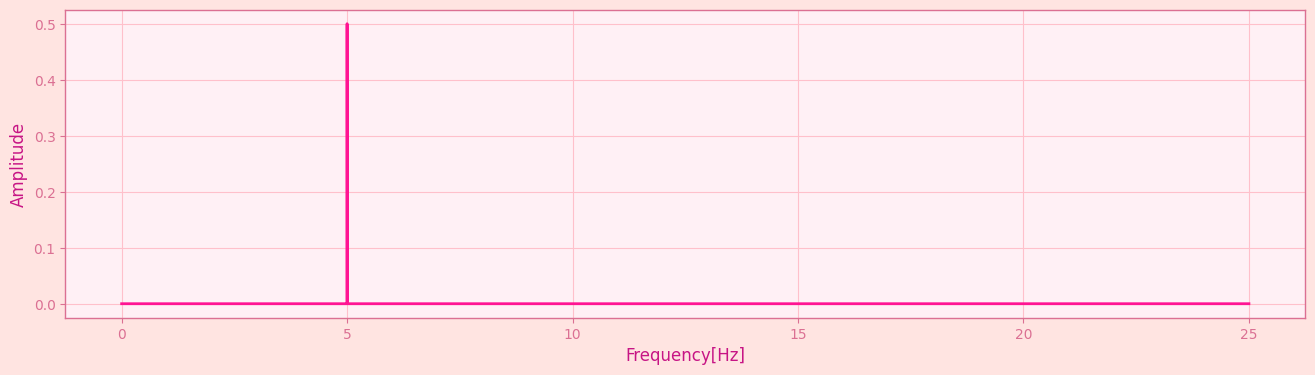

In [20]:
calculate_and_plot_spectrum(signal, freq=freq)

### **Etap3: Badanie liniowości DFT - mieszanina sygnałów**
Po udanej weryfikacji transformaty dla pojedyńczej fali sinusoidalnej, przechodzimy do badnia kluczowej właściwości DFS: **liniowości**. W rzeczywistych sygnałach (takich jak EKG) rzadko mamy do czynienia z jedną częstotliwością - zazwyczaj badany sygnał jest sumą wielu składowych o róznym pochodzeniu.
W tym kroku zaimplementowaliśmy funkcję 'generate_mixed_signals', która tworzy kombinację liniową dwóch sinusoid o częstotliwości 50 Hz i 60 Hz. Następnie wykonaliśmy na tak otrzymanym sygnale transformatę (FFT).

Jakie były cele tego eksperymentu?
- **Separacja składowych:** Sprawdzanie, czy algorytm FFT poprawnie zidentyfikuje dwie odrębne częstotliwości w jednym sygnale.
- **Weryfikacja próbkowania:** Wybrano częstotliwość próbkowania $fs = 200 Hz$, co zgodnie z twierdzeniem Nyquista-Shannona jest wartoscią wystarczającą dla najnizszej składowej (60 Hz), poniewaz $200 > 2 x 60$.
- **Analiza selektywności:** Długa seria próbek ($N = 65536$) pozwala ba uzyskanie bardzo wysokiej rozdzielczości częstotliwościowej, co powinno przełozyć się na dwa wyraźne, wąskie "prązki" w widmie.

In [21]:
def generate_mixed_signals(freqs: list, amplitudes: list, fs: float, N: int) -> tuple:
    """Generates a mixed signal with specified frequencies and amplitudes.
    Parameters:
    freqs (list): The frequencies of the sinusoidal components (in Hz).
    amplitudes (list): The amplitudes of the sinusoidal components.
    fs (float): The sampling frequency (in Hz).
    N (int): The number of samples.
    Returns:
    tuple: A tuple containing the time vector and the generated signal."""
    time = np.arange(N) / fs
    signal = sum(a * np.sin(2 * np.pi * f * time) for f, a in zip(freqs, amplitudes))
    return time, signal

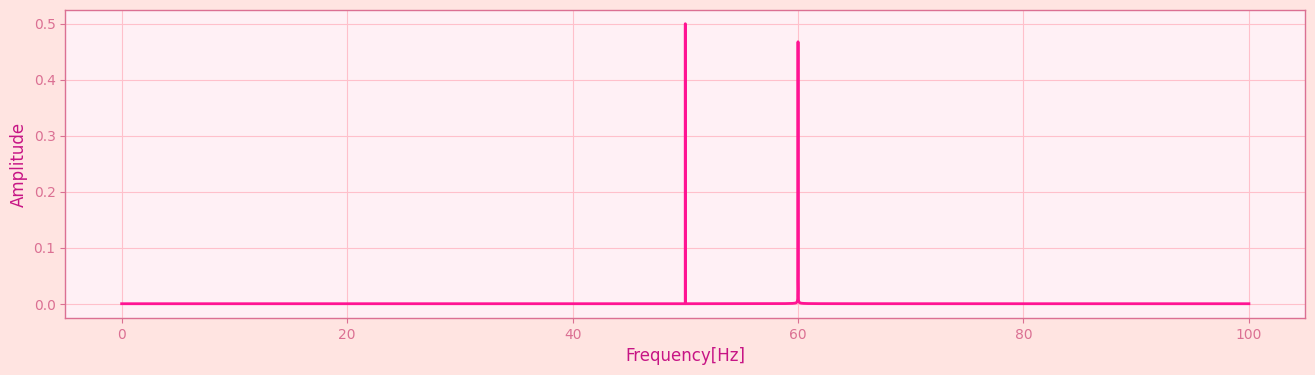

In [22]:
time, signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=200, N=65536)
calculate_and_plot_spectrum(signal, freq=200)

### **Etap4: Analiza wpływu częstotliwości próbkowania i zjawisko aliasingu**
Dalej sprawdzamy jak zmiana częstotliwości próbkowania ($fs$) wpływa na widmo sygnału mieszanego. 
Sprawdziliśmy dwa przypadki:
- $fs = 100 Hz$: Gdzie dla sygnału 60 Hz nie spełnione jest twierdzenie Nyquista i występuje zjawisko aliasingu (nakładania się widm). Sygnał "odbija się" od częstotliwości Nyquista i pojawia się w widmie w błędnym miejscu (jako 40 Hz).
- $fs = 300 Hz$ oraz $fs = 400 Hz$. Te dwa przypadki mozemy traktować jako jedn, bo dla tak duzej $fs$ warunek Nyquista jest spelniony z zapasem i widmo pokaze się poprawnie (dwa prązki na odpowiednich miejscach). Jedyna róznica będzie w zakresie osi X.

Dzięki temu doświadczeniu mozemy empirycznie potwierdzic, ze aby poprawnie analizowac sygnał EKG (który zawiera wysokie składowe częstotliwościowe), musimy dobrać odpowiednio wysoką częstotliwość próbkowania.

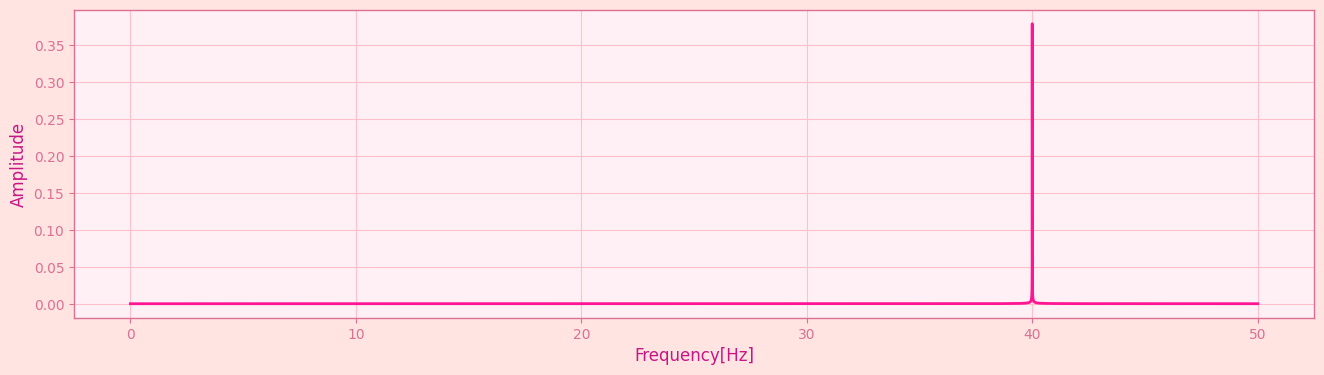

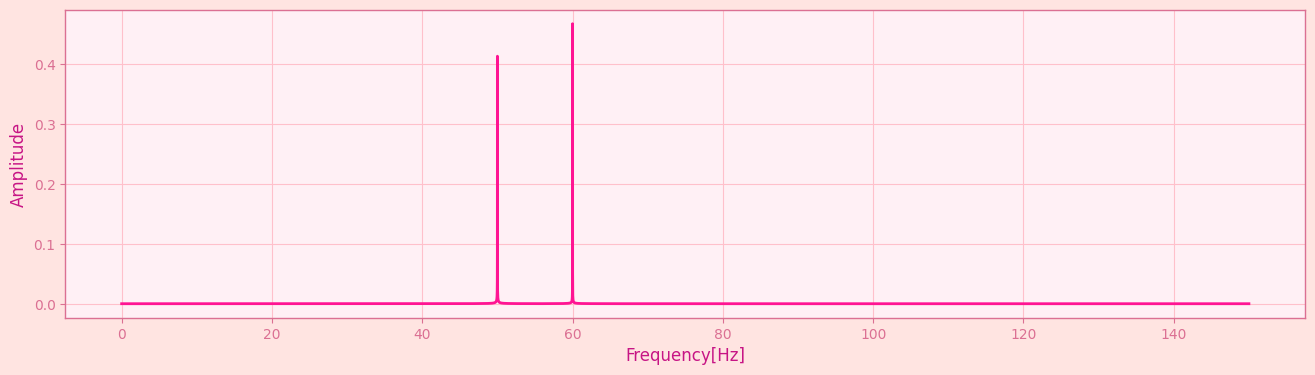

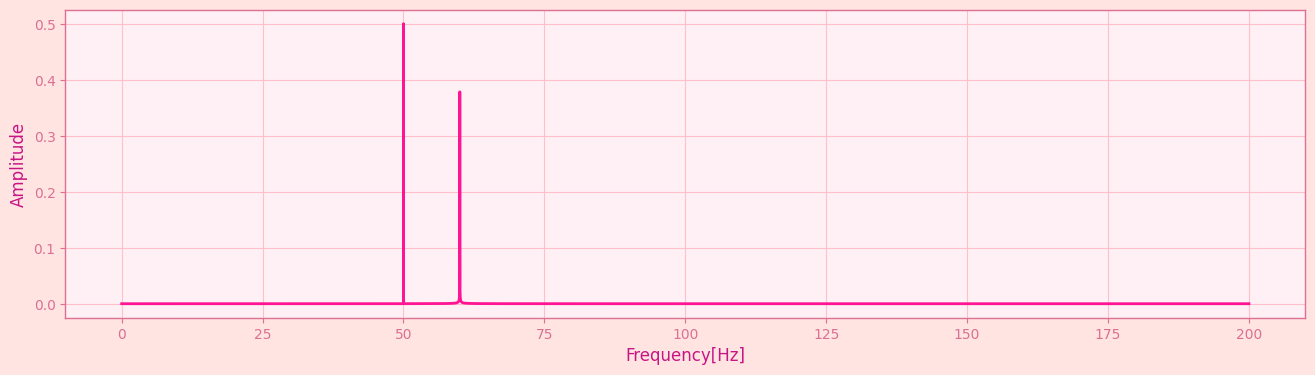

In [23]:
time,signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=100, N=65536)
calculate_and_plot_spectrum(signal, freq=100)
time, signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=300, N=65536)
calculate_and_plot_spectrum(signal, freq=300)
time, signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=400, N=65536)
calculate_and_plot_spectrum(signal, freq=400)

### **Etap5: Odwracalność transformaty - powrót do dziedziny czasu**
Cechą transformaty Fouriera jest jej odwracalność. Oznacza to, ze posiadając widmo sygnału (wynik FFT) powinniśmy być w stanie bezbłędnie oddtworzyć sygnał pierwotny w dziedzinie czasu, stosując Odwrotną Szybką Transformatę Fouriera (IFFT)
W celu weryfikacji tej właściwości zaimplementowaliśmy funkcję 'plot_ifft', która:
1. Oblicza FFT sygnału wejściowego.
2. Wykonuje operację odwrotną (IFFT) na otrzymanym widmie
3. Wyodrębnia część rzeczywistą (np.real) z wyniku, poniewaz operacje na liczbach zespolonyh w komputerze mogą generować śladowe, nieistotne wartosci urojone (rzędu $10^-16$).
4. Nakłada na siebie oba sygnały (oryginalny i zrekonstrułowany) na jednym wykresie.


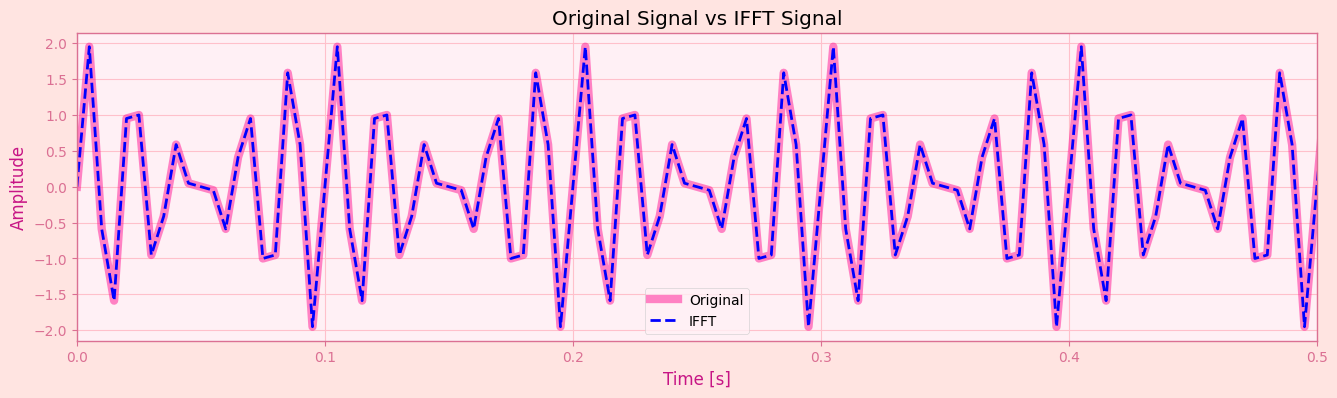

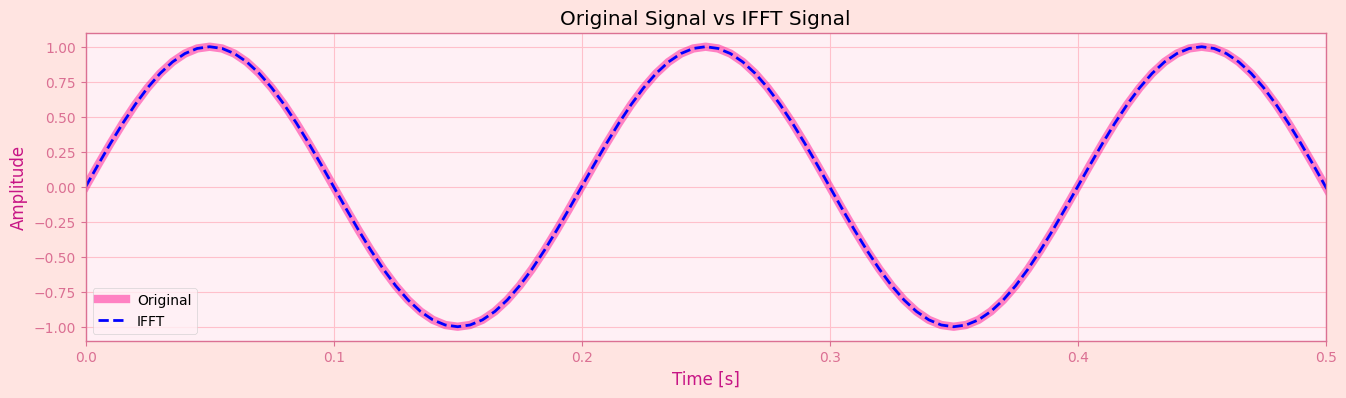

In [24]:
def plot_ifft(time: np.ndarray, signal: np.ndarray) -> None:
    """Plots the original signal and the IFFT signal for comparison.
    Parameters:
    time (np.ndarray): The time vector.
    signal (np.ndarray): The original input signal."""
    N = len(signal)
    
    fft_result = np.fft.fft(signal)
    ifft_result = np.fft.ifft(fft_result)
    ifft_real = np.real(ifft_result)    
    

    plt.figure(figsize=(16, 4))
    
    plt.plot(time, signal, label='Original', linewidth=6, alpha=0.5) 
    plt.plot(time, ifft_real,'b--', label='IFFT') 
    
    plt.xlim(0, 0.5)
    plt.title("Original Signal vs IFFT Signal")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()
time, signal1 = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=200, N=65536)
plot_ifft(time, signal1)
signal_sin=np.sin(2 * np.pi * 5 * time)
plot_ifft(time, signal=signal_sin)

Jak mozemy zauwazyć na powyzszych wykresach, sygnał oryginalny oraz po wykonaniu na nim IFFT pokrywają się prawie idealnie. Potwierdza to nasze przypuszczenia, ze proces przejscia między domenami czasu i częstotliwości jest bezstratny - zarówno dla prostych funkcji, jak i bardziej skomplikowanych złozen.

---
# **Ćwiczenie 3: Analiza widmowa rzeczywistego sygnału EKG**

Zastosujemy teraz sprawdzony w poprzednim zadaniu mechanizm na sygnale medycznym wczytanym z pliku 'ekg100.txx'.
Sygnał EKG charakteryzuje się tym, ze jego główna energia (załamki P, T oraz zespół QRS) skupiona jest w stosunkowo niskich częstotliwościach (najczęściej w przedziale od 0.5 Hz do ok. 50 Hz). Analiza tego widma pozwala zidentyfikować:
- Częstość akcji serca
- Ewentualne wtrącenia i zakłócenia wielkiej częstotliwości (np. artefakty mięśniowe).

Podobnie jak poprzednio, zweryfikujemy czy potrafimy przejść do dziedziny częstotliwości i wrócić do sygnału w czasie z zachowaniem pełnej informacji.

### **Etap1: Przygotowanie i wstępna wizualizacja sygnały rzeczywistego**
Przystępujemy do analizy drugiego zbioru danych (pliku 'ekg100.txt'). W odróznieniu od idealnych fal sinusoidalnych z poprzedniego ćwiczenia, mamy tutaj rzeczywisty zapis jednokanałowy, który niesie ze sobą naturalne zmienności i szumy.

Na początek wczytujemy pierwsze 10 wierszy z kolumny z amplitudami, przede wszystkim po to by upewnić się, ze plik '.txt' otwiera i wczytuje się poprawnie. Natępnie dostosowujemy parametry (zgodnie ze specyfikacją częstotliwość próbkowania dla tych danych wynosi $fs = 360 Hz$) i z wykorzystaniem naszej interaktywnej platformy weryfikujemy dane wizualnie.

In [25]:
df_ekg = pd.read_csv('data/ekg100.txt', sep='\s+', header=None)
df_ekg.columns = ['Amplitude'] 
df_ekg.head(10)

,Amplitude
0,-0.145
1,-0.145
2,-0.145
3,-0.145
4,-0.145
5,-0.145
6,-0.145
7,-0.145
8,-0.120
9,-0.135


In [26]:
create_signal_widget(df_ekg, signal_frequency=360)

Output()

![Rysunek 3: Interaktywny podgląd sygnału EKG](EKG/plots/widget3.png)

### **Etap2: Analiza widmowa fragmentu sygnału EKG**
Aby zobaczyć widmo danych z pliku uzywamy funkcji napisanej w porzednim zadaniu, po prostu odpowiednimi dla analizowanaego sygnału parametrami.

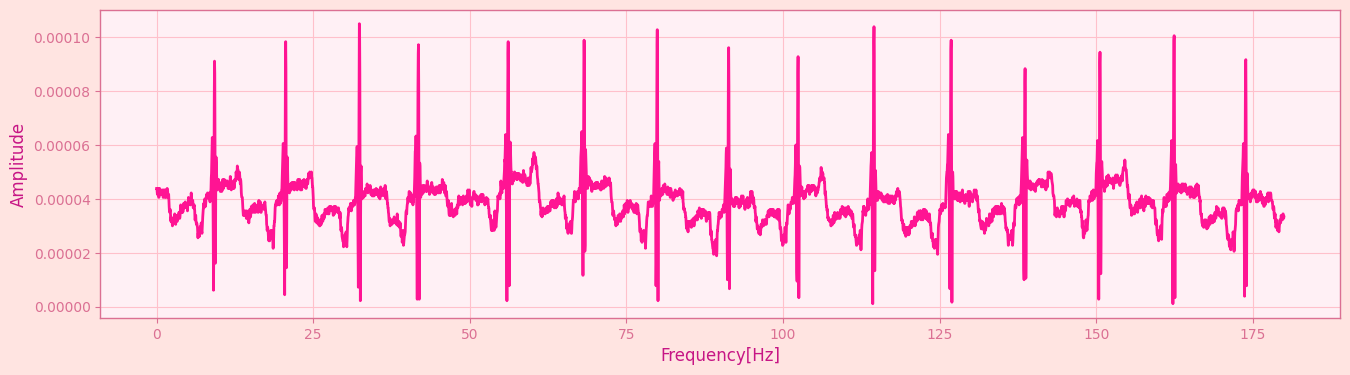

In [27]:
signal_ekg = df_ekg[1000:10000].to_numpy()
calculate_and_plot_spectrum(signal_ekg,360)

W przeciwnieństwie do sygnałów syntetycznych, które generowały pojedyncze, ostre prązki, widmo sygnału EKG jest ciągłe i bogate w składowe. Aby analiza była rzetelna, do obliczeń wybieramy reprezentatywny fragment sygnału (od 1 tyś. do 10 tyś. próbki), co pozwala uniknąć ewentualnych stanów nieustalonych na początku nagrania.
**Co mówi nam widmo sygnału na wykresie?**
- **Okresowość sygnału:** Sygnał EKG w tym konkretnym fragmencie jest bardzo regularny (stały rytm serca)
- **Harmoniczne rytmu serca:** Kazda kolejna "szpilka" to kolejna wielokrotność częstotliwości podstaowewej (częstotliwości uderzeń serca). Pierwszy prązek wyznacza pusl, a kolejne odpowiadają za odtworzenie ostrego ształtu.
- **Wąskie pasmo QRS:** Fakt, ze prązki są widoczne az do wysokich częstotliwości ($175 Hz$), świadczy o tym, ze załamki R w tym sygnale są bardzo stromr i "ostre" (im szybciej zmienia się sygnał w czasie, tym dalej sięgają jego składowe w częstotliwości).
- **Stabilność rytmu:** Bardzo wąskie i wyraźne prązki świadczą o duzej stabilności rytmu serca w analizowanym oknie czasowym.

### **Etap3: Weryfikacja rekonstrukcji dla sygnału złozonego**
Ostatnim krokiem w tym ćwiczeniu jest ostateczny test naszej funkcji 'plot_ifft'. Chcemy sprawdzić, czy mechanizm transformaty Fouriera poradzi sobie z równie duzą precyzją w przypadku sygnału rzeczywistego, który zawiera szumy i nieregularne kształty.
Po wygenerowaniu wektora czasu dopasowanego do długości wyciętego fragmentu ($fs = 360 Hz$), nakładamy sygnał oryginalny na ten oddtworzony z widma.

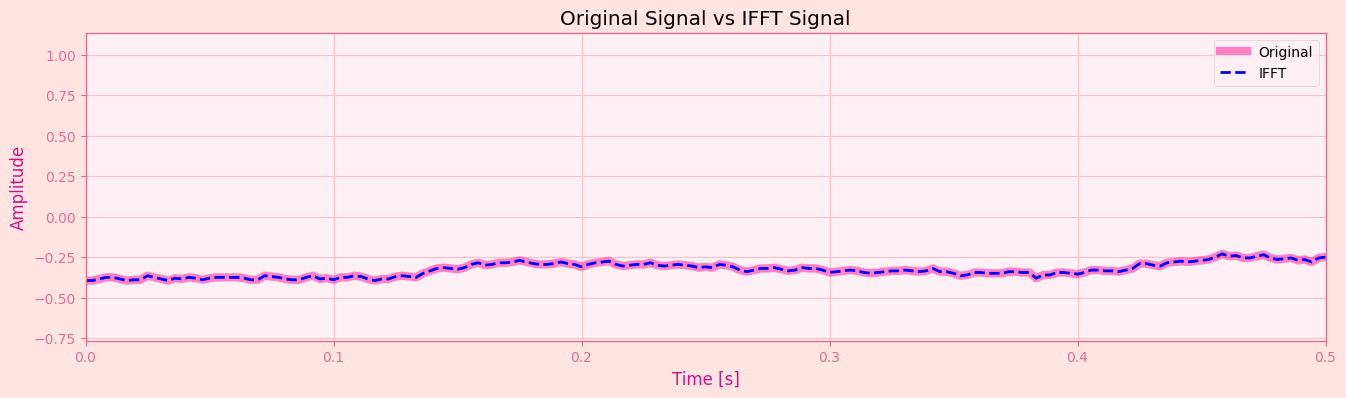

In [28]:
# get time for EKG signal
fs_ekg = 360 
time_ekg = np.arange(len(signal_ekg)) / fs_ekg

plot_ifft(time_ekg, signal_ekg)

Nawet dla tak złozonego sygnału jak EKG, rekonstrukcja przy uzyciu IFFT jest bardzo dobra. Na wykrsie obie linie pokrywają się w $100%$, co potwierdza, ze mozemy bezpiecznie operować w dziedzinie częstotliwości (np. w celu filtracji), nie martwiąc się o utratę informacji przy powrocie do dziedziny czasu.

---
# Ćwiczenie 4: Filtracja zakłóceń z sygnału EKG

Rzeczywiste sygnały często zawierają dwa główne źródła zakłóceń:
1. **Szum sieci energetycznej (50/60 Hz):** Wprowadza szybkozmienne, cykliczne "zabrudzenia" widoczne na zapisie.
2. **Pływanie linii izoelektrycznej (często < 1-5 Hz):** Związane z oddechem pacjenta lub ruchem elektrod, sprawia, że cały sygnał "faluje" w osi Y.

**Zadanie:** 
1. Wykreślić charakterystyki filtrów Butterwortha, aby pokazać jak tłumią pasma.
2. Zastosować filtr dolnoprzepustowy (LPF) o odcięciu 60 Hz oraz górnoprzepustowy (HPF) o odcięciu 5 Hz. Połączenie szeregowe tych dwóch tworzy **filtr pasmowoprzepustowy (Bandpass) [5-60 Hz]**.
3. Obliczyć różnicę między sygnałem przed i po filtracji oraz wyrysować widmo tej różnicy, by udowodnić co dokładnie usunęliśmy.

### **Etap1: Identyfikacja zakłóceń w sygnale**
Przystępujemy do najbardziej praktycznej części laboratorium - oczyszczania sygnału z rzeczywistych artefaktów. Po wczytanie fragmentu do podglądu, okazało się, ze plik 'ekg_noise.txt' rózni się strukturą od poprzednich: zawiera dwie kolumny (czas i amplitudę).
Zgodnie z wymaganiami naszej platformy, ilozujemy kolumnę z samym sygnałem, bo nasz widget na podstawie częstotliwości próbkowania samodzielnie (dynamicznie) generuje osie czsasu

In [29]:
df_ekg_noise = pd.read_csv('data/ekg_noise.txt', sep='\s+', header=None)
df_ekg_noise.columns = ['time','signal']
df_ekg_noise.head(10)

,time,signal
0,0.000000,-0.325000
1,0.002778,-0.273038
2,0.005556,-0.268038
3,0.008333,-0.320000
4,0.011111,-0.391962
5,0.013889,-0.396962
6,0.016667,-0.340000
7,0.019444,-0.263038
8,0.022222,-0.258038
9,0.025000,-0.315000


In [30]:
df_ekg_noise = df_ekg_noise[['signal']] # We don't need time column for plotting, so we can just use the signal column

In [31]:
create_signal_widget(df_ekg_noise, signal_frequency=360)

Output()

![Rysunek 4: Interaktywny podgląd sygnału EKG](EKG/plots/widget4.png)

Uruchomienie interaktywnego podglądu dla tego pliku pozwala zdiagnozować dwa kluczowe problemy techniczne zapisu:
- **Szum sieciowy**: To jest ta gęsta, regularna "sinusoida" nałozona na cały przebieg sygnału.
- **Pływanie izolinii**: Sygnał nie trzyma się poziomu 0 na osi Y. cały przebieg powoli "faluje" w górę i w dół (zakłócenie niskoczęstotliwościowe).

### **Etap2: Analiza widmowa sygnału zakłóconego
Aby skutecznie zaprojektować filtry, musimy najpierw zidentyfikować składowe częstotliwościowe szumu. Wykorzystamy do tego (tak jak w poprzednich zadaniach) FFT.

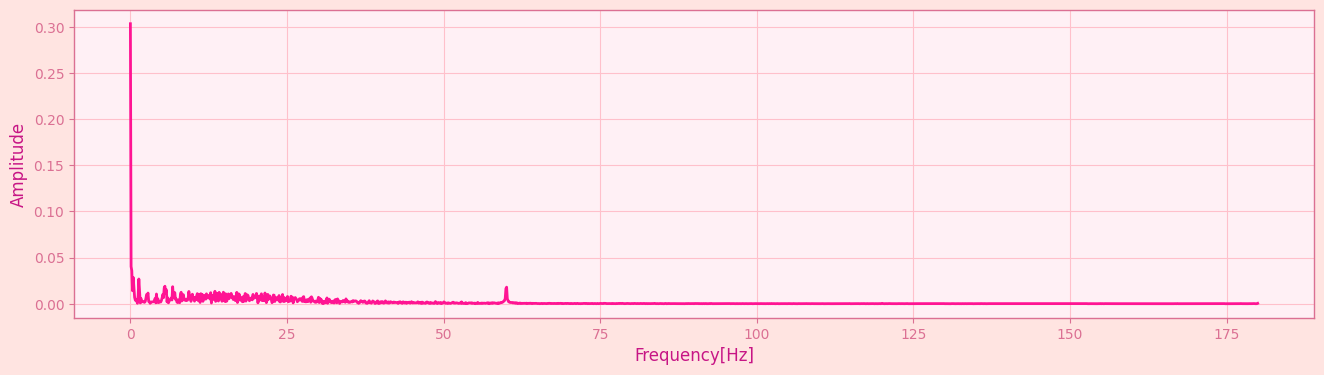

In [32]:
signal_ekg_noise = df_ekg_noise['signal'].to_numpy()
calculate_and_plot_spectrum(signal_ekg_noise, freq=360)

Wyznaczone widmo amplitudowe sygnału ujawnia gdzie koncentrują się zakłócenia. Mamy jeden ekstremalnie duzy pik w okolicy 0 Hz, które odpowiadają za obserwowane wcześniej pływanie izolinii (zmiany wolnozmienne o duzej amplitudzie). Kolejny "prązek" pojawią się nw 60 Hz. Jest on mniejszy, ake wyraźny i odizolowany i potwierdza nam obecność szumu sieci energetycznej (odpowiada za "poszarpane" linie i gęste drgania na wykresie czasowym).
Oznacza to, ze pasmo uzyteczne dla tego pliku to od $0.5$ do $50 Hz$

### **Etap3: Implementacja banku filtrów cyfrowych**
Mając ju zdefiniowane częstotliwości zakłóceń, przechodzimy do implementacji narzędzi do ich usuwania. Wybraliśmy filtry Butterwortha, poniewaz charakteryzują cię one płaską charakterystyką amplitudy w paśmie przepustowym, co jest wazne dla zachowania natulanego kształtu sygnału EKG.
Zaimplementowaliśmy trzy warianty, które pozwalają na elestyczne podejście do problemu. Mozemy usunąc tylko szum sieciowy (Lowpass), tylko pływanie izolinii (Highpass) lub obu na raz (Boundpass)

In [33]:
def butter_lowpass_filter(data: np.ndarray, cutoff: float = 60, fs: float = 360, order: int = 4) -> np.ndarray:
    """Applies a Butterworth lowpass filter to the input data.
    Parameters:
    data (np.ndarray): The input signal to be filtered.
    cutoff (float): The cutoff frequency of the lowpass filter (in Hz).
    fs (float): The sampling frequency of the input signal (in Hz).
    order (int): The order of the Butterworth filter."""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

def butter_highpass_filter(data: np.ndarray, cutoff: float = 5, fs: float = 360, order: int = 4) -> np.ndarray:
    """Applies a Butterworth highpass filter to the input data.
    Parameters:
    data (np.ndarray): The input signal to be filtered.
    cutoff (float): The cutoff frequency of the highpass filter (in Hz).
    fs (float): The sampling frequency of the input signal (in Hz).
    order (int): The order of the Butterworth filter."""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high')
    return filtfilt(b, a, data)

def butter_band_filter(data: np.ndarray, lowcut: float = 5, highcut: float = 30, fs: float = 360, order: int = 4) -> np.ndarray:
    """Applies a Butterworth bandpass filter to the input data.
    Parameters:
    data (np.ndarray): The input signal to be filtered.
    lowcut (float): The lower cutoff frequency of the bandpass filter (in Hz).
    highcut (float): The upper cutoff frequency of the bandpass filter (in Hz).
    fs (float): The sampling frequency of the input signal (in Hz).
    order (int): The order of the Butterworth filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

### **Etap4: Narzędzia do ewaluacji i eksportu wyników**
Sama opracja filtracji to tylko połowa sukcesu - kluczowe jest sprawdzenie, czy proces ten nie zniekształ drastycznie sygnału EKG (np. czy nie obniył obnizył zbytnio amplitudy załamka R). W tym celu przygotowaliśmy dwa narzędzia pomocnicze:
- **Wizualizacja porównawcza:** Funkcja ta nakłada sygnał przefiltrowany na oryginał.
- **Eksport danych:** Umozliwia zapisanie wyniku procesu filtracji do pliku tekstowego w odpowiedni formacie.

In [34]:
def plot_filtered_signal(original_signal: np.ndarray, filtered_signal: np.ndarray, y_axis_title: str, x_axis_title: str) -> None:
    """Plots the original signal and the filtered signal for comparison.
    parameters:
    original_signal (np.ndarray): The original input signal before filtering.
    filtered_signal (np.ndarray): The signal after applying the filter.
    y_axis_title (str): The title for the y-axis.
    x_axis_title (str): The title for the x-axis.
    """
    plt.figure(figsize=(16, 4))
    plt.plot(original_signal, label='Original', linewidth=6, alpha=0.5) 
    plt.plot(filtered_signal,'--b', label='Filtered') 
    plt.title("Original Signal vs Filtered Signal")
    plt.xlabel(x_axis_title)
    plt.ylabel(y_axis_title)
    plt.legend()
    plt.show()

In [35]:
def save_filtered_signal(original_signal: np.ndarray, filtered_signal: np.ndarray, filename: str, ) -> None:
    """Saves the original signal and the filtered signal to a CSV file for comparison.
    Parameters:
    original_signal (np.ndarray): The original input signal before filtering.
    filtered_signal (np.ndarray): The signal after applying the filter.
    filename (str): The name of the file to save the signals to."""

    df_filtered = pd.DataFrame({
        'Original': original_signal,
        'Filtered': filtered_signal
    })
    df_filtered.to_csv(filename, index=False)

### **Etap5: Interaktywny widżet do wyswitlania oraz zapiswyania fragmentów filtrowanego oraz orgirnalnego sygnał**
**Opis funkcjonalności widgetu**
1. Update: Aktualizuje widget (np. po wyborze nowego zakresu)
2. Save: Zapisze wycinek sygnału do pliku o wybranej nazwie
3. Start/End: pozwalją okreslić wycinek sygnału (w sekundach) 
4. Y axis scale: Okresla skale osi Y (np. dla Y axis scale 100 oś Y ma zakres od -100 do +100)
5. Filename: Nazwa pliku do którego my być zpisnay sygnał
 


In [36]:
def create_filtered_signal_widget(original_signal: np.ndarray, filtered_signal: np.ndarray) -> None:
    """Creates an interactive widget to visualize and save the original and filtered signals.
    Parameters:
    original_signal (np.ndarray): The original input signal before filtering.
    filtered_signal (np.ndarray): The signal after applying the filter."""
    
    #initialize widgets
    out = widgets.Output() 

    #declare input widgets
    start_input = widgets.BoundedIntText(
        value=0,
        min=0,
        max=original_signal.shape[0],
        step=0.1,
        description='Start:',
        layout=widgets.Layout(width='200px')
    )
    end_input = widgets.BoundedIntText(
        value=max(5, original_signal.shape[0]), #default to the full length of the signal 
        min=0,
        max=original_signal.shape[0],
        step=0.1,
        description='End:',
        layout=widgets.Layout(width='200px')
    )

    y_scale_input = widgets.BoundedFloatText(
        value=original_signal.max(), #default to the maximum value in the DataFrame for scaling
        min=0.1,
        max=10000,
        step=0.1,
        description='Y axis scale:',
        layout=widgets.Layout(width='200px')
    )
    filename_input = widgets.Text(
        value='ekg_filtered_signals.csv',
        description='Filename:',
        layout=widgets.Layout(width='200px')
    )
    Y_axis_title = widgets.Text(
        value='Amplitude',
        description='Y Axis Title:',
        layout=widgets.Layout(width='200px')
    )
    X_axis_title = widgets.Text(
        value='Time (s)',
        description='X Axis Title:',
        layout=widgets.Layout(width='200px')
    )
    #assign button widgets
    btn_update = widgets.Button(description='Update', button_style='info')
    btn_save = widgets.Button(description='Save', button_style='info')

    #define button click events
    def update_plot():
        with out:
            clear_output(wait=True) 
            plot_filtered_signal(original_signal[int(start_input.value):int(end_input.value)], filtered_signal[int(start_input.value):int(end_input.value)], Y_axis_title.value, X_axis_title.value)

    def btn_update_clicked(b):
        update_plot()

    def btn_save_clicked(b):
        save_filtered_signal(original_signal[int(start_input.value):int(end_input.value)], filtered_signal[int(start_input.value):int(end_input.value)], "results/" + filename_input.value)
        print("Signals saved to:", "results/" + filename_input.value)

    #assign button click events
    btn_update.on_click(btn_update_clicked)
    btn_save.on_click(btn_save_clicked)

    #display widgets
    controls_box = widgets.HBox([btn_update, btn_save, start_input, end_input, y_scale_input, filename_input, Y_axis_title, X_axis_title],layout=widgets.Layout(flex_flow='row wrap', align_items='center'))

    display(controls_box, out)

    #inital update to display the widget
    update_plot()

In [37]:
filtered_low = butter_lowpass_filter(signal_ekg_noise, cutoff=60, fs=360, order=4)
create_filtered_signal_widget(signal_ekg_noise, filtered_low)

Output()

![Rysunek 5: Interaktywny podgląd sygnału EKG](EKG/plots/widget5.png)

### **Etap6: Weryfikacja skuteczności filtracji**
Zanim zastosujemy zaprojeltowany filtr dolnoprzepustowy (LPF) na sygnale medycznym, zweryfikujemy jego charakterystykę.

### *Charakterystyka amplitudowa (Magnitude Response)*
Wykres demonstruje jak bardzo filtr tłumi konkretną częstotliwość (wyrazone w decybelach)

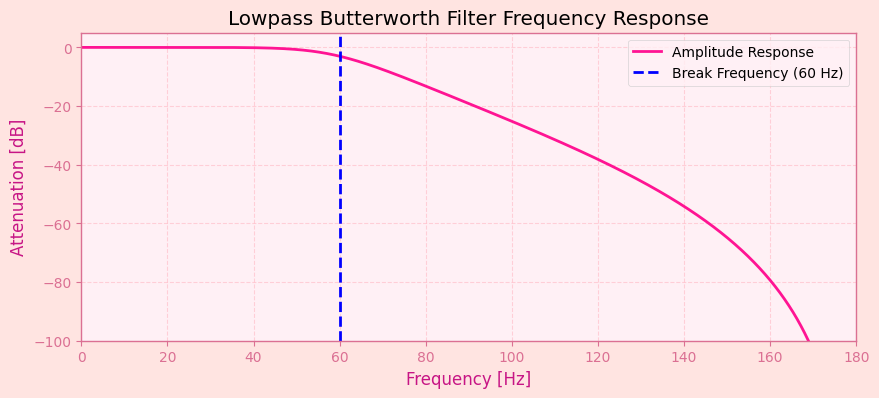

In [38]:
cutoff = 60
fs = 360
nyq = 0.5 * fs #nyquist frequency
normal_cutoff = cutoff / nyq
b, a = butter(4, normal_cutoff, btype='low')
    
w, h = freqz(b, a, worN=8000)
freq_hz = 0.5 * fs * w / np.pi #Calculate the frequency in Hz
attenuation_db = 20 * np.log10(np.abs(h)) # Calculate the attenuation in dB
    
plt.figure(figsize=(10, 4))
plt.plot(freq_hz, attenuation_db,  label='Amplitude Response')
plt.axvline(cutoff, color='b', linestyle='--', label=f'Break Frequency ({cutoff} Hz)')
plt.title('Lowpass Butterworth Filter Frequency Response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Attenuation [dB]')
plt.ylim([-100, 5]) # Limit the y-axis to show the attenuation more clearly
plt.xlim([0, fs/2]) # Nyquist frequency is the maximum frequency that can be represented
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Widzimy, ze wzmocnieniewynosi $0 dB$, co oznacza, ze sygnał uzyteczny (większość sygnału) przechodzi przez filtr bez zadnych start amplitudy (jest to zakres $0-60 Hz$), pozostałe częstotiwości zostaną odpowiednio mocno przytłumione. Niebieską linią na wykresie zaznaczono częstotliwość graniczną ($60 Hz$).

**Zestawienie wszystkich testów charakterystyki filtra**
Przygotowano falę sinusoidalną o $fs = 10 Hz$ i połączono ją z dwiema falami ($fs=100 Hz i 150Hz$), symulującymi szum.

Rozmieszczenie wykresów oraz analiza:
1. **Charakterystyka filtra (Góra-Lewo):** Potwierdza, ze przy $60 Hz$ następuje spadek mocy, a częstotliwośći $100 Hz i 150 Hz$ znajdują się głęboko w paśmie zaporowym.
2. **Widmo sygnału oryginalnego (Góra-Prawo):** Wyraźnie identyfikuje trzy piki $10 Hz$ (cel) oraz $100 i 150 Hz$ (szum).
3. **Porównanie czasowe (Środek-Lewo):** Pokazuje jak "poszarpany" sygnał szary zamienia się w idealnie gładką linię (sinus). Dzięki funkcji 'filtfilt' funkcja odfiltrowana nie jest przesunięta w czasie względem oryginału.
4. **Widmo po filtracji (Środek-Prawo):** Piki demonstrujące szum zostały usunięte i pozostała jedynie czysta składowa $10 Hz$.
5. **Analiza odfiltrowanego szumu (Dół-Lewo):** Wykres demonstruje to czego filtr pozbył się z naszej oryginalnej funkcji.
6. **Widmo róznicy (Dół-Prawo):** Brak piku w $10 Hz$ upewnia nas, ze filtr nie usunął nic z oryginalnego sygnału.


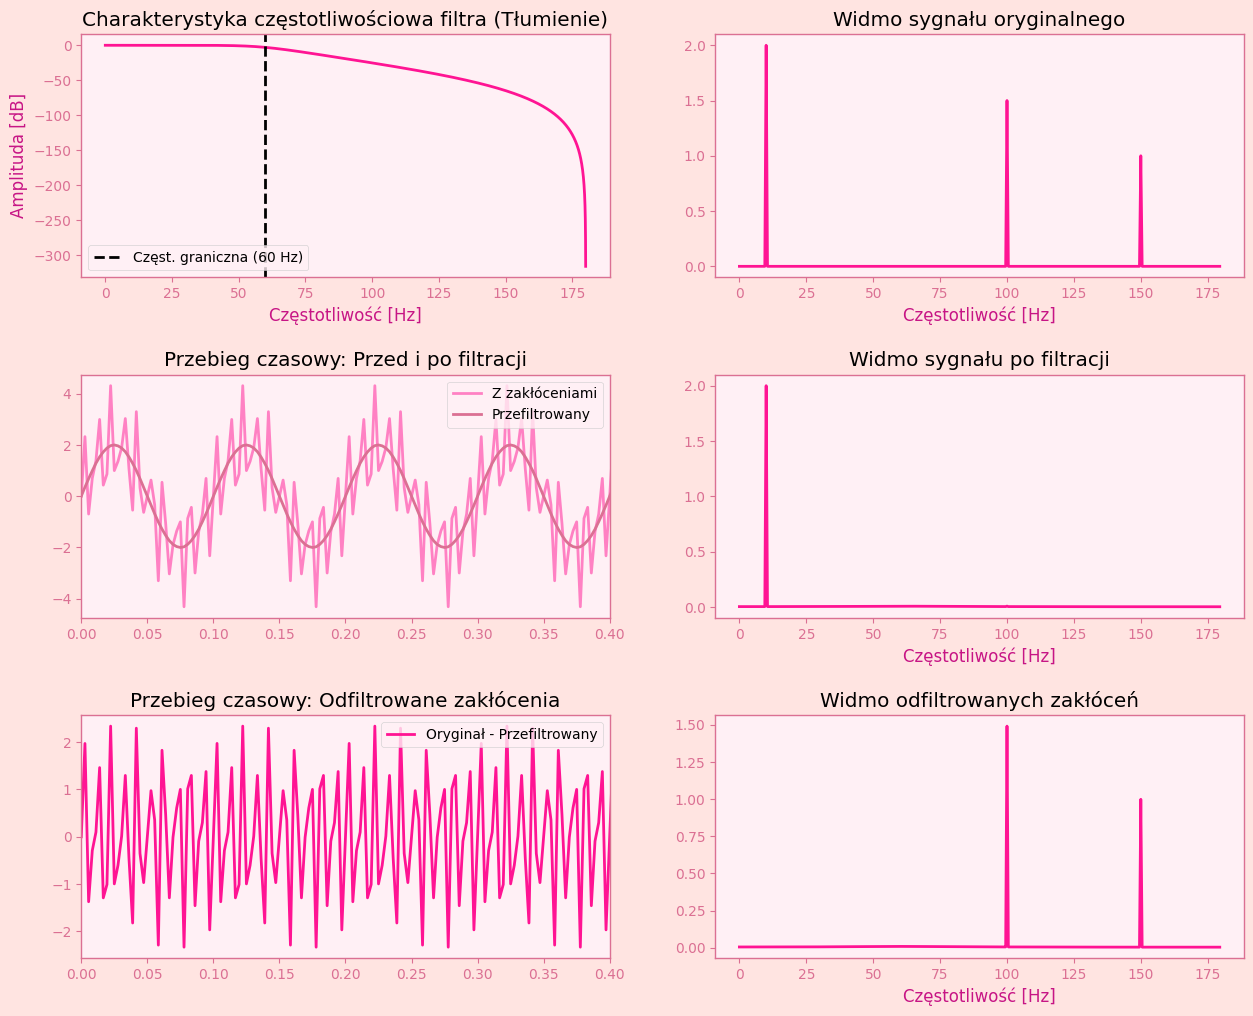

In [47]:

# 1. Parametry
fs = 360.0       # Częstotliwość próbkowania (Hz)
cutoff = 60.0    # Częstotliwość graniczna filtra (Hz)
order = 4        # Rząd filtra
T = 2.0          # Czas trwania sygnału w sekundach
n = int(T * fs)  # Całkowita liczba próbek
t = np.linspace(0, T, n, endpoint=False) # Oś czasu

# 2. Generowanie sztucznego sygnału wejściowego
sig_freq = 10.0   # Częstotliwość sygnału użytecznego
noise_freq1 = 100.0 # Zakłócenie 1
noise_freq2 = 150.0 # Zakłócenie 2

# Składamy sygnał: główna fala (sinus 10 Hz) + szumy o wyższych częstotliwościach
signal = 2 * np.sin(2 * np.pi * sig_freq * t)
noise = 1.5 * np.sin(2 * np.pi * noise_freq1 * t) + 1.0 * np.sin(2 * np.pi * noise_freq2 * t)
data = signal + noise

# 3. Twoja funkcja filtrująca
def butter_lowpass_filter(data: np.ndarray, cutoff: float = 60, fs: float = 360, order: int = 4) -> np.ndarray:
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

# 4. Wyznaczenie charakterystyki częstotliwościowej (Tłumienie)
nyq = 0.5 * fs
normal_cutoff = cutoff / nyq
b, a = butter(order, normal_cutoff, btype='low')
w, h = freqz(b, a, worN=8000)
freq_response_x = 0.5 * fs * w / np.pi
freq_response_y = 20 * np.log10(np.abs(h)) # Zamiana na decybele (dB)

# 5. Filtracja sygnału i obliczenie różnicy
filtered_data = butter_lowpass_filter(data, cutoff, fs, order)
difference = data - filtered_data

# 6. Funkcja pomocnicza do obliczania widma (FFT)
def get_spectrum(s):
    yf = fft(s)
    xf = fftfreq(n, 1 / fs)[:n//2]
    return xf, 2.0/n * np.abs(yf[0:n//2])

xf, yf_orig = get_spectrum(data)
_, yf_filt = get_spectrum(filtered_data)
_, yf_diff = get_spectrum(difference)

fig, axs = plt.subplots(3, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.2)

# Lewa kolumna: Charakterystyka i czas, Prawa kolumna: Widmo (częstotliwość)
axs[0, 0].plot(freq_response_x, freq_response_y, )
axs[0, 0].axvline(cutoff, color='k', linestyle='--', label='Częst. graniczna (60 Hz)')
axs[0, 0].set_title("Charakterystyka częstotliwościowa filtra (Tłumienie)")
axs[0, 0].set_xlabel('Częstotliwość [Hz]')
axs[0, 0].set_ylabel('Amplituda [dB]')
axs[0, 0].grid()
axs[0, 0].legend()

axs[0, 1].plot(xf, yf_orig)
axs[0, 1].set_title("Widmo sygnału oryginalnego")
axs[0, 1].set_xlabel('Częstotliwość [Hz]')
axs[0, 1].grid()

axs[1, 0].plot(t, data, label='Z zakłóceniami', alpha=0.5)
axs[1, 0].plot(t, filtered_data, label='Przefiltrowany', linewidth=2)
axs[1, 0].set_title("Przebieg czasowy: Przed i po filtracji")
axs[1, 0].set_xlim(0, 0.4) # Zoom na ułamek sekundy, by lepiej widzieć fale
axs[1, 0].grid()
axs[1, 0].legend()

axs[1, 1].plot(xf, yf_filt, )
axs[1, 1].set_title("Widmo sygnału po filtracji")
axs[1, 1].set_xlabel('Częstotliwość [Hz]')
axs[1, 1].grid()

axs[2, 0].plot(t, difference, label='Oryginał - Przefiltrowany')
axs[2, 0].set_title("Przebieg czasowy: Odfiltrowane zakłócenia")
axs[2, 0].set_xlim(0, 0.4)
axs[2, 0].grid()
axs[2, 0].legend()

axs[2, 1].plot(xf, yf_diff)
axs[2, 1].set_title("Widmo odfiltrowanych zakłóceń")
axs[2, 1].set_xlabel('Częstotliwość [Hz]')
axs[2, 1].grid()

plt.show()

### **Etap7: Test odporności na szum szerokopasmowy (Stochastyczny)**
Kolejnym testem jest sprawdzenie jak filtr Butterwortha radzi sobie z szumem losowym (białym). W odróznieniu od poprzednich testów, gdzie szumem były konkretne częstotliwości, tutaj generujemy zakłócenia metodą 'np.random.normal'. Symuluje to rzeczywiste warunki pracy aparatury medycznej, gdzie sygnał nakładają się fluktuacje termiczne i drobne artefajty mięśniowe.

***Kontrukcja sygnału testowego i jego wizualizacja***
Sygnał bazowy to $20 Hz$ składowa uzyteczna oraz $80, 140 Hz$ składowej do odfiltrowania. Na taki sygnał nakładamy potem losowy szu Gaussowski.

In [48]:
#Generate test signal with noise
time, signal = generate_mixed_signals(freqs=[20, 80, 140], amplitudes=[1, 0.5, 0.2], fs=360, N=65536)
noise = 0.5 * np.random.normal(size=signal.shape)
noisy_signal = signal + noise   

#plot the noisy signal
create_signal_widget(pd.DataFrame(noisy_signal, columns=['Noisy Signal']), signal_frequency=360)

Output()

![Rysunek 6: Interaktywny podgląd sygnału](EKG/plots/widget6.png)

***Analiza widmowa szumu losowego***
Demostruje w których miescach znajdują się składowe naszego sygnału.

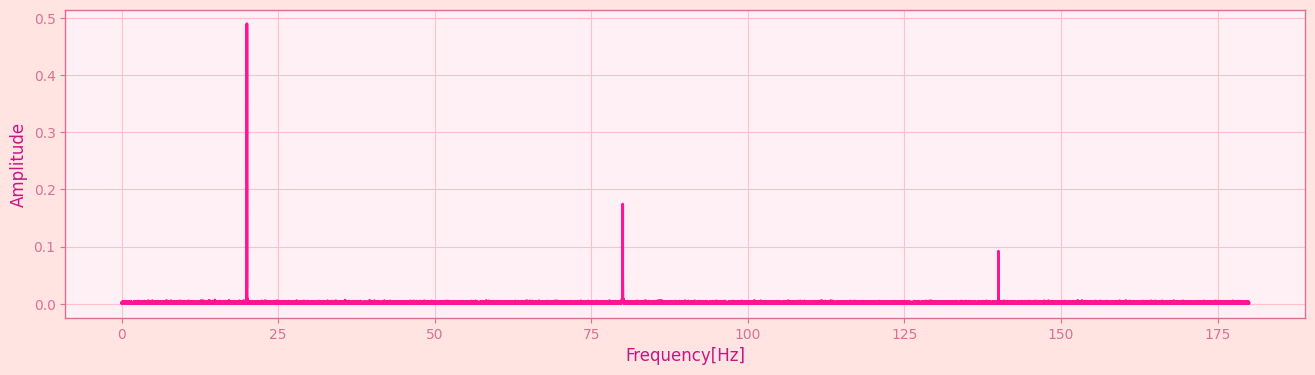

In [49]:
#Plot the noisy signal 
calculate_and_plot_spectrum(noisy_signal, freq=360)

***Zastosowanie  filtra dolnoprzepustowego***
Ponizsze wykresy prezentują skuteczność filtra dolnoprzepustowego w najtrudniejszym scenariuszu - gdy sygnał jest niemal całkowicie przykryty szerokopasmowym szumem losowym.

Pierwszy wykres przedstawia wykres porównawczy sygnału oryginalnego i przefiltrowanego.
Sygnał oryginalny ma ekstremalnie wysoki poziom zakłóceń. Szum Gaussowski sprawia, ze pasmo sygnału jest "rozmyte" i tworzy gęsty blok, w którym trudno dostrzec jakąkolwiek periodyczność. Amplituda szumu jest na tyle duza, ze całkowicie maskuje ona informację o pracy "serca" (naszą składową 20 Hz). Sygnał przefiltrowany został bardzo uproszczony (tak jak zakładano).

Drugi wykres juz oczyszczony sygnał. Demonstruje to niesamowitą skuteczność dobrze zastosowanego filtra.

In [50]:
filtered_signal = butter_lowpass_filter(noisy_signal, cutoff=60, fs=360, order=4)
create_filtered_signal_widget(noisy_signal, filtered_signal)
create_signal_widget(pd.DataFrame(filtered_signal, columns=['Filtered Signal']), signal_frequency=360)

Output()

Output()

![Rysunek 7: Interaktywny podgląd sygnału EKG](EKG/plots/widget7.png)
![Rysunek 8: Interaktywny podgląd sygnału EKG](EKG/plots/widget8.png)

Dodatkowo, aby się upewnić, ze wszystkie składowe zostały usunięte sprawdzamy spektrum sygnału przefiltrowanego.

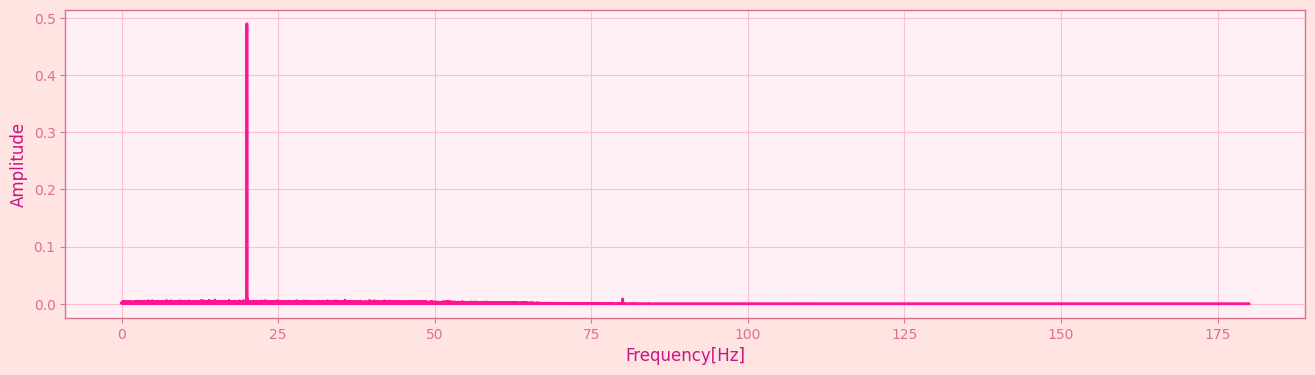

In [51]:
calculate_and_plot_spectrum(filtered_signal, freq=360)

Demonstracja pasma odfiltrowanego.

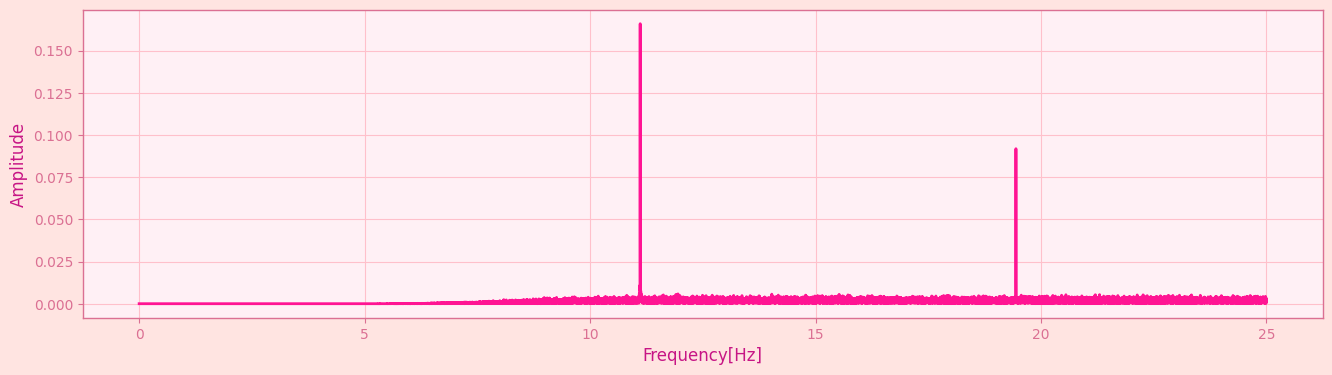

In [52]:
difference_signal = noisy_signal - filtered_signal
calculate_and_plot_spectrum(difference_signal, freq=freq)

### **Etap8: Ostateczna filtracja sygnału rzeczywistego**
W ostatnim kroku stosujemy zaprojektowane filtry na najbardziej wymagającym sygnale: 'ekg_noise.txt'. Tutaj najlepiej widać skuteczność filtra górnoprzepustowego (HPF) oraz pasmowoprzepustowego (Bandpass).

In [55]:
filtered_high = butter_highpass_filter(signal_ekg_noise, cutoff=5, fs=360, order=4)
create_filtered_signal_widget(signal_ekg_noise, filtered_high)

Output()

![Rysunek 9: Interaktywny podgląd sygnału EKG](EKG/plots/widget9.png)

Po zastosowaniu filtra górnoprzepustowego mozemy zauwazyć, jak wykres wyprostował się i usunięty został efekt pływania.
Następnie nałozyliśmy filre dolnoprzepustowy na sygnał przefilrowany przez filtr górnoprzepustowy, aby połączyć je i usunąc wszystkie niechciane elementy.

In [56]:
filtered_high = butter_highpass_filter(filtered_low, cutoff=5, fs=360, order=4)
create_filtered_signal_widget(filtered_low, filtered_high)

Output()

![Rysunek 10: Interaktywny podgląd sygnału EKG](EKG/plots/widget10.png)

Zamiast uzywać dwóch filtrów szeregowo, mozemy uzyć po prostu biltra pasmowego. Ponizej znajduje się prezentacja jego wyniku.

In [58]:
filtered_band = butter_band_filter(signal_ekg_noise, lowcut=5, highcut=60, fs=360, order=4)
create_filtered_signal_widget(signal_ekg_noise, filtered_band)

Output()

![Rysunek 10: Interaktywny podgląd sygnału EKG](EKG/plots/widget10.png)

### Podsumowanie
Laboratorium pozwoliło na praktyczne prejście przez wszystkie etapy cyfrowe przetwarzania sygnałów biomedycznych.
- Narzędzia wizualizacyjne pozwalają na płynną analizę wczytanych sygnałów.
- Błąd rekonstrukcji IFFT bliski zera udowadnia, że transformata Fouriera nie powoduje utraty danych, co pozwala swobodnie operować między dziedziną czasu i częstotliwości.
- Poprawnie zaprojektowany filtr pasmowoprzepustowy wyeliminował izolinnie oraz szum wysokoczęstotliwościowy. Jak widać na ostatnim wykresie widma *sygnału usuniętego*, filtr wyeliminował potężne skupiska energii poniżej 5 Hz i odciął wszystko powyżej 60 Hz, zostawiając istotne klinicznie pasmo EKG nienaruszone.

In [ ]:
#uniform notebook design
pink_theme = """
<style>
    body { background-color: #FFE4E1 !important; }
    #notebook-container {
        background-color: #FFF0F5 !important;
        box-shadow: 0px 0px 15px rgba(255, 105, 180, 0.3) !important;
        border-radius: 15px;
    }
    div.cell.code_cell {
        background-color: #FFF5EE !important;
        border-left: 5px solid #FF1493 !important;
    }
    div.text_cell_render {
        font-family: 'Georgia', serif;
        color: #000000 !important;
    }
    .widget-label { 
        color: #C71585 !important;
        font-weight: bold;
    }
    .jupyter-button {
        background-color: #FFB6C1 !important;
        color: white !important;
        font-weight: bold;
        border-radius: 10px;
    }
    .jupiter-button:hover {
        background-color: #FF69B4 !important;
    }
</style>
"""
display(HTML(pink_theme))